# Keşif

In [1]:
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2
import os

## Veriyi Al

In [2]:
from olist.data import Olist
data = Olist().get_data()

Olist e-ticaret platformundaki her işlem şu özelliklere sahiptir:
- satın alacak olan bir `customer_id`...
- çeşitli `product_id`...
- bir `seller_id`...
- ve bir `review_id`...
- tüm bunlar bir `order_id`'ye aittir.

## Çeşitli DataFrame'lerinizin kardinalitelerini araştırın

❓ **Kaç tane benzersiz `orders`, `reviews`, `sellers`, `products` and `customers` var ?**

In [3]:
data.keys()

dict_keys(['sellers', 'product_category_name_translation', 'orders', 'order_items', 'customers', 'geolocation', 'order_payments', 'order_reviews', 'products'])

In [4]:
# YOUR CODE HERE
n_orders = data['orders']['order_id'].nunique()
n_reviews = data['order_reviews']['review_id'].nunique()
n_sellers = data['sellers']['seller_id'].nunique()
n_products = data['products']['product_id'].nunique()
n_customers = data['customers']['customer_id'].nunique()

print(f"Benzersiz order sayısı: {n_orders}")
print(f"Benzersiz review sayısı: {n_reviews}")
print(f"Benzersiz seller sayısı: {n_sellers}")
print(f"Benzersiz product sayısı: {n_products}")
print(f"Benzersiz customer sayısı: {n_customers}")

Benzersiz order sayısı: 99441
Benzersiz review sayısı: 98410
Benzersiz seller sayısı: 3095
Benzersiz product sayısı: 32951
Benzersiz customer sayısı: 99441


❓ **Sipariş başına kaç tane yorum(reviews) var? Tüm siparişler için yorum var mı?**
<details>
    <summary markdown=‘span’>İpuçları</summary>

Bu bilgiye bireysel csv dosyanızdan doğrudan erişemezsiniz. Öğrenmek için tabloları birleştirmeniz gerekir. Hangi tür birleştirme yapmanız gerektiğini düşünün.

Hangi tablolara ihtiyacınız olduğundan emin değil misiniz? Öğrenmek için ERD'nize geri dönün.

Yorum sayısını öğrenmek için: `order_id` başına yorum sayısını sayın ve bir histogram çizin. Pandas serisinde `.hist()` kullanabilirsiniz.
</details>

<Axes: >

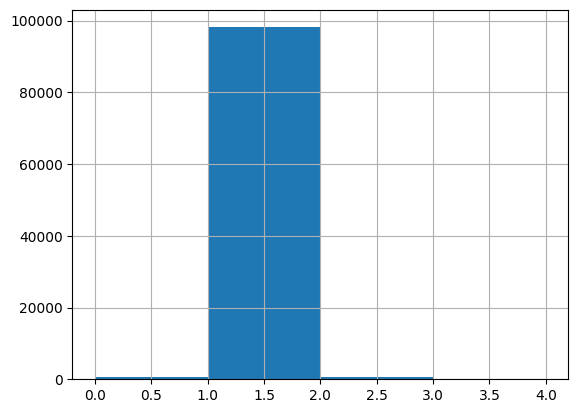

In [6]:
order_reviews = data['orders'].merge(data['order_reviews'], on = 'order_id', how = 'left')
reviews_per_order = order_reviews.groupby('order_id')['review_id'].count()
reviews_per_order.hist(bins=range(0, 5))

🧪 **Test your code below**

Yorum eksik olan siparişlerin sayısını `int` olarak `n_missing_reviews` adlı bir değişkende saklayın.

In [10]:
# review_id kısmı boş (null) olanları sayıyoruz
# .isna() boş olanları bulur, .sum() ise kaç tane olduğunu toplar
n_missing_reviews = int(order_reviews['review_id'].isna().sum())

print(f"Yorumu eksik olan sipariş sayısı: {n_missing_reviews}")

Yorumu eksik olan sipariş sayısı: 768


In [8]:
n_missing_reviews = reviews_per_order[reviews_per_order == 0].count()
print(f"İnceleme olmayan sipariş sayısı: {n_missing_reviews}")

İnceleme olmayan sipariş sayısı: 768


In [11]:
from nbresult import ChallengeResult

result = ChallengeResult('exploratory',
    n=n_missing_reviews
)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/sema/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/sema/GitHub/data-exploratory-analysis/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_exploratory.py::TestExploratory::test_n_missing_reviews PASSED      [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/exploratory.pickle

git commit -m 'Completed exploratory step'

git push origin master

